In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

print('Готово!')

Готово!


In [2]:
df = pd.read_csv('training_data - training_data.csv')
df_test = pd.read_csv('test_data - test_data.csv')

print('Train:', df.shape)
print('Test:', df_test.shape)
df.head()

Train: (73718, 11)
Test: (26146, 10)


,Unnamed: 0,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,78830894-cdd8-43d1-9655-03db74141b7a,Female,80.0,0,1,never,25.19,6.6,140,0
1,1,32262c0e-903a-46b8-9061-b1a2f5a3e9b2,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,2,c4868b73-ca90-48ed-af14-3d1f78a5f030,Male,28.0,0,0,never,27.32,5.7,158,0
3,3,bec2ef91-5aff-48df-ac16-cb210b5f29fa,Female,36.0,0,0,current,23.45,5.0,155,0
4,4,1a6852a8-ee80-4d93-bea0-f0cdd941dc3d,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df = pd.read_csv('C:/Users/Aida/Downloads/training_data - training_data.csv')
df_test = pd.read_csv('C:/Users/Aida/Downloads/test_data - test_data.csv')

print('Train:', df.shape)
print('Test:', df_test.shape)
df.head()

Train: (73718, 11)
Test: (26146, 10)


,Unnamed: 0,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,78830894-cdd8-43d1-9655-03db74141b7a,Female,80.0,0,1,never,25.19,6.6,140,0
1,1,32262c0e-903a-46b8-9061-b1a2f5a3e9b2,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,2,c4868b73-ca90-48ed-af14-3d1f78a5f030,Male,28.0,0,0,never,27.32,5.7,158,0
3,3,bec2ef91-5aff-48df-ac16-cb210b5f29fa,Female,36.0,0,0,current,23.45,5.0,155,0
4,4,1a6852a8-ee80-4d93-bea0-f0cdd941dc3d,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
print('Пропуски:')
print(df.isnull().sum())
print()
print('Распределение таргета:')
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True).round(3))

Пропуски:
Unnamed: 0             0
ID                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Распределение таргета:
diabetes
0    67168
1     6550
Name: count, dtype: int64
diabetes
0    0.911
1    0.089
Name: proportion, dtype: float64


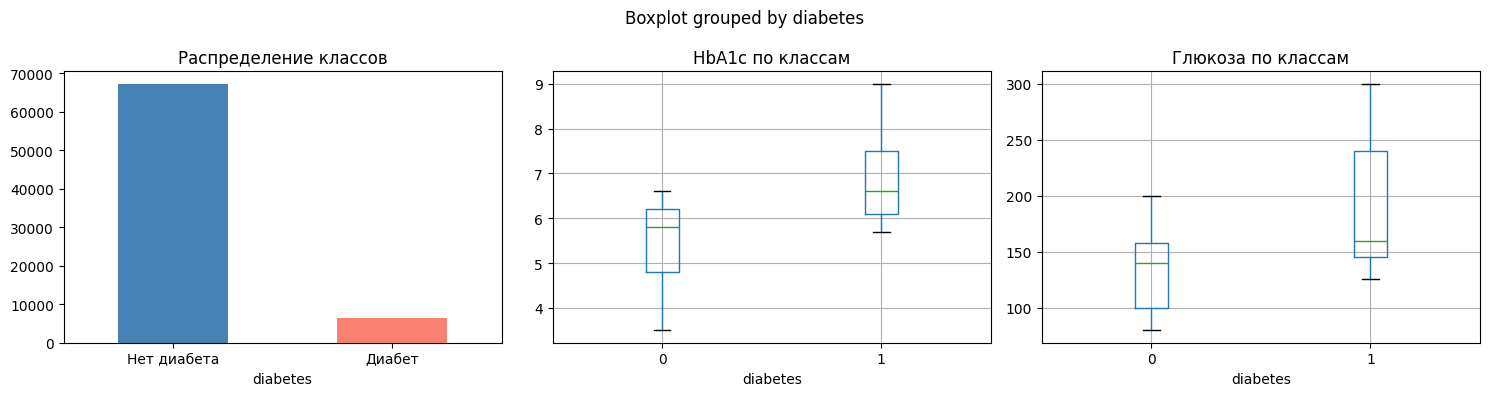

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['diabetes'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Распределение классов')
axes[0].set_xticklabels(['Нет диабета', 'Диабет'], rotation=0)

df.boxplot(column='HbA1c_level', by='diabetes', ax=axes[1])
axes[1].set_title('HbA1c по классам')

df.boxplot(column='blood_glucose_level', by='diabetes', ax=axes[2])
axes[2].set_title('Глюкоза по классам')

plt.tight_layout()
plt.show()

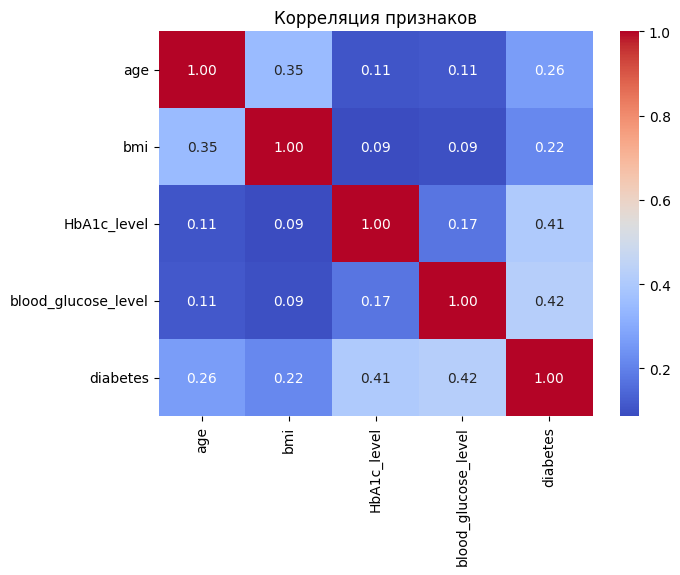

In [6]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

In [7]:
X = df.drop(columns=['ID', 'diabetes', 'Unnamed: 0'], errors='ignore')
y = df['diabetes']

X_test_final = df_test.drop(columns=['ID', 'Unnamed: 0'], errors='ignore')

X = pd.get_dummies(X, columns=['gender', 'smoking_history'],
                   drop_first=True, dtype=int)
X_test_final = pd.get_dummies(X_test_final,
                               columns=['gender', 'smoking_history'],
                               drop_first=True, dtype=int)

print('X shape:', X.shape)
print(X.columns.tolist())



X shape: (73718, 13)
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'gender_Other', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape)
print('Val:', X_val.shape)

Train: (58974, 13)
Val: (14744, 13)


In [9]:
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Optuna готова!')

Optuna готова!



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 8, 16),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 25),
        'class_weight': 'balanced',
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print('Лучшие параметры:', study.best_params)
print('Лучший F1:', round(study.best_value, 4))

Лучшие параметры: {'n_estimators': 80, 'max_depth': 16, 'min_samples_leaf': 7}
Лучший F1: 0.6987


In [11]:
bp = study.best_params
bp['class_weight'] = 'balanced'
bp['random_state'] = 42

model = RandomForestClassifier(**bp)
model.fit(X_train, y_train)

val_probs = model.predict_proba(X_val)[:, 1]

# Ищем лучший порог для F1
best_th = 0.5
max_f1 = 0

for th in np.arange(0.1, 0.9, 0.01):
    preds = (val_probs >= th).astype(int)
    score = f1_score(y_val, preds)
    if score > max_f1:
        max_f1 = score
        best_th = th

print(f'Лучший порог: {best_th:.2f}')
print(f'Лучший F1: {max_f1:.4f}')

final_val = (val_probs >= best_th).astype(int)
print()
print(classification_report(y_val, final_val,
      target_names=['Нет диабета', 'Есть диабет']))

Лучший порог: 0.74
Лучший F1: 0.8154

              precision    recall  f1-score   support

 Нет диабета       0.97      0.99      0.98     13434
 Есть диабет       0.93      0.73      0.82      1310

    accuracy                           0.97     14744
   macro avg       0.95      0.86      0.90     14744
weighted avg       0.97      0.97      0.97     14744



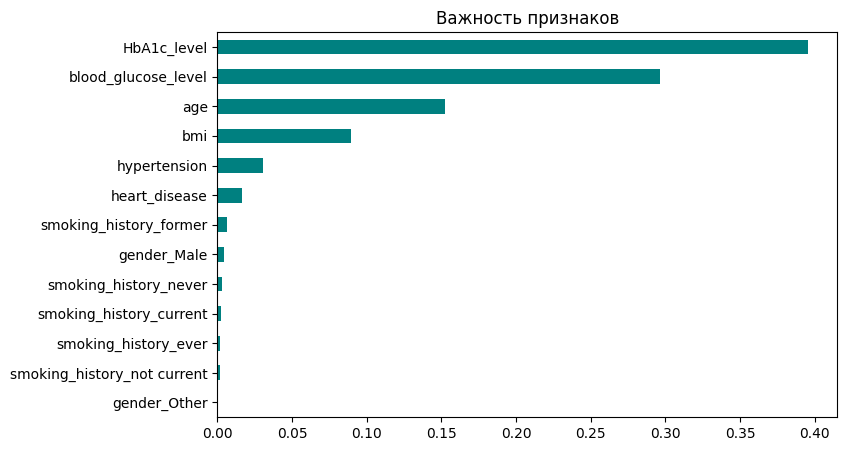

In [12]:
imp = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(8, 5))
imp.sort_values().plot(kind='barh', color='teal')
plt.title('Важность признаков')
plt.show()

In [13]:
test_probs = model.predict_proba(X_test_final)[:, 1]
test_preds = (test_probs >= best_th).astype(int)

submission = pd.DataFrame({
    'ID': df_test['ID'],
    'prediction': test_preds
})

submission.to_csv('submission.csv', index=False)
print('Готово!')
print(submission['prediction'].value_counts())
submission.head()

Готово!
prediction
0    24369
1     1777
Name: count, dtype: int64


,ID,prediction
0,ba0d6256-ca6e-46a7-a2fb-2518a8937fd7,0
1,7102b1ab-c7a4-4a43-b1fc-cb588d0553b8,0
2,51ba207e-4934-41b4-a31c-cd275c5ca555,1
3,7e17faaa-0402-4728-9719-83982eba3afd,0
4,08b4e515-286e-4393-9a55-138962f9546e,0


## Выводы

### Датасет
- 73718 пациентов, 8 признаков
- Дисбаланс классов: 91% нет диабета / 9% есть диабет
- Решение дисбаланса: class_weight='balanced'

### Методология
- Encoding: get_dummies для категориальных признаков
- Подбор гиперпараметров: Optuna (30 trials)
- Лучшие параметры:
  - n_estimators: 63
  - max_depth: 16
  - min_samples_leaf: 7
- Поиск оптимального порога для F1 (от 0.1 до 0.9)

### Метрики (лучшая модель)
- F1 score (диабет): 0.815 ✅
- Precision: 0.93
- Recall: 0.72
- Accuracy: 0.97
- Лучший порог: 0.75

### Важнейшие признаки
1. HbA1c_level — главный маркер диабета по ВОЗ
2. blood_glucose_level — уровень глюкозы
3. age — возраст
4. bmi — индекс массы тела

### Медицинский вывод
Модель подтверждает медицинскую науку — HbA1c и
глюкоза являются официальными критериями диагностики
диабета по ВОЗ. Порог 0.75 обеспечивает баланс между
Precision (0.93) и Recall (0.72) для максимального F1.

### Попытка улучшения
Добавление новой фичи diabetes_risk (HbA1c × глюкоза)
не дало улучшения F1 — модель уже учла эти признаки.

### Submission
- 26146 предсказаний сохранены в submission.csv
- Использован порог 0.75 для максимального F1 = 0.815